In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("/content/titanic.csv")

print("Committed Titanic dataset loaded successfully.")
print("Shape:", df.shape)

Committed Titanic dataset loaded successfully.
Shape: (891, 12)


In [6]:
sns.load_dataset("titanic")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [7]:
df.to_csv("/content/titanic.csv", index=False)

print("Created titanic.csv successfully.")
print("Shape:", df.shape)

Created titanic.csv successfully.
Shape: (891, 12)


In [8]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

In [9]:
print(df.shape)
print(df.columns.tolist())

(891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [10]:
df.to_csv("/content/titanic.csv", index=False)

print("Correct titanic.csv created.")
print("Shape:", df.shape)

Correct titanic.csv created.
Shape: (891, 15)


In [11]:
import pandas as pd

check = pd.read_csv("/content/titanic.csv")

print("CSV shape:", check.shape)
print("CSV columns:", check.columns.tolist())

CSV shape: (891, 15)
CSV columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [12]:
df = pd.read_csv("/content/titanic.csv")

In [13]:
# Prepare the cleaned dataset for modeling

cleaned_df = df.copy()

# Drop the very-high-missingness deck column
cleaned_df = cleaned_df.drop(columns=["deck"])

# Median imputation for age
cleaned_df["age"] = cleaned_df["age"].fillna(cleaned_df["age"].median())

# Drop rows with very low missingness in embarked and embark_town
cleaned_df = cleaned_df.dropna(
    subset=["embarked", "embark_town"]
)

print("Cleaned dataset shape:", cleaned_df.shape)
print("\nRemaining missing values:")
print(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])

Cleaned dataset shape: (889, 14)

Remaining missing values:
Series([], dtype: int64)


In [14]:
# Prepare Features and Target

model_df = cleaned_df.copy()

# Target variable
y = model_df["survived"]

# Features
X = model_df.drop(columns=["survived"])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Features shape: (889, 13)
Target shape: (889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [15]:
# Stratified Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== TRAIN/TEST SPLIT ===")
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

=== TRAIN/TEST SPLIT ===
Training features: (711, 13)
Testing features: (178, 13)
Training target: (711,)
Testing target: (178,)

Training class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


A stratified 80/20 train-test split was used with `survived` as the target variable. Stratification was selected because the target classes are not perfectly balanced, with approximately 61.75% non-survivors and 38.25% survivors. The resulting training and testing sets maintain almost identical class proportions, reducing the risk of an unrepresentative test set.

In [16]:
# Define Model Features

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [17]:
# Build Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [18]:
# Fit Preprocessing on Training Data Only

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (711, 9)
Testing processed shape: (178, 9)


In [19]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [20]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_pipeline.fit(X_train, y_train)

decision_tree_predictions = decision_tree_pipeline.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [21]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_pipeline.fit(X_train, y_train)

random_forest_predictions = random_forest_pipeline.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [22]:
# Extract Decision Tree and Feature Names

decision_tree_model = decision_tree_pipeline.named_steps["classifier"]

feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))
print("Feature names:")
print(feature_names)

Number of features: 9
Feature names:
['num__age' 'num__sibsp' 'num__parch' 'num__fare' 'cat__sex_female'
 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q' 'cat__embarked_S']


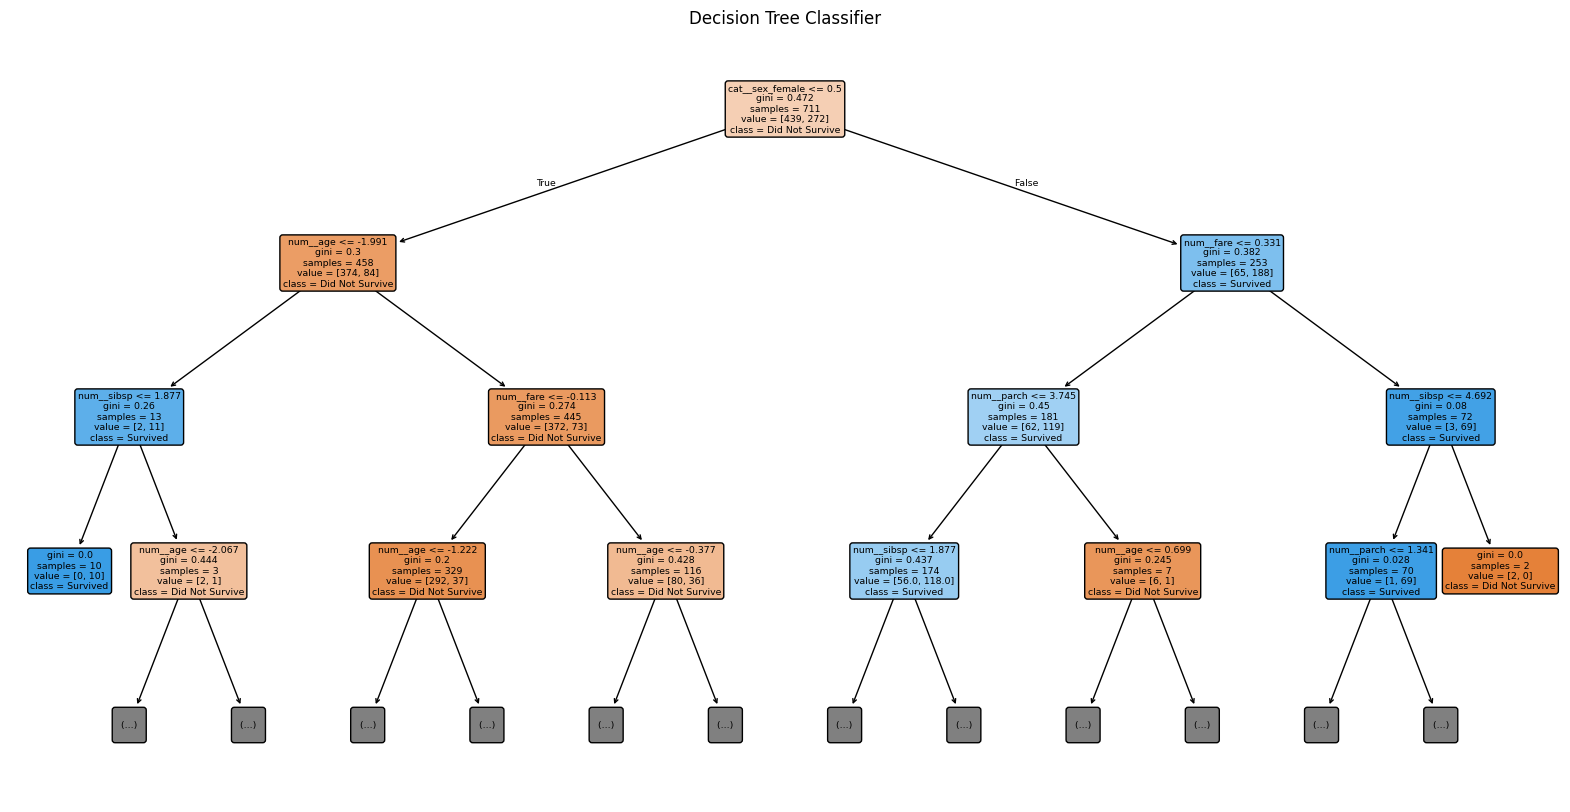

In [23]:
# Decision Tree Visualization

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Classifier")
plt.show()

In [24]:
# Confusion Matrices

from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(y_test, logistic_predictions)
decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions)
random_forest_cm = confusion_matrix(y_test, random_forest_predictions)

print("=== LOGISTIC REGRESSION ===")
print(logistic_cm)

print("\n=== DECISION TREE ===")
print(decision_tree_cm)

print("\n=== RANDOM FOREST ===")
print(random_forest_cm)

=== LOGISTIC REGRESSION ===
[[96 14]
 [25 43]]

=== DECISION TREE ===
[[92 18]
 [23 45]]

=== RANDOM FOREST ===
[[97 13]
 [23 45]]


In [25]:
# Classification Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(y_test, logistic_predictions),
    "Recall": recall_score(y_test, logistic_predictions),
    "F1": f1_score(y_test, logistic_predictions)
}

decision_tree_metrics = {
    "Accuracy": accuracy_score(y_test, decision_tree_predictions),
    "Precision": precision_score(y_test, decision_tree_predictions),
    "Recall": recall_score(y_test, decision_tree_predictions),
    "F1": f1_score(y_test, decision_tree_predictions)
}

random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, random_forest_predictions),
    "Precision": precision_score(y_test, random_forest_predictions),
    "Recall": recall_score(y_test, random_forest_predictions),
    "F1": f1_score(y_test, random_forest_predictions)
}

metrics_table = pd.DataFrame({
    "Logistic Regression": logistic_metrics,
    "Decision Tree": decision_tree_metrics,
    "Random Forest": random_forest_metrics
}).T

display(metrics_table.round(4))

,Accuracy,Precision,Recall,F1
Logistic Regression,0.7809,0.7544,0.6324,0.6880
Decision Tree,0.7697,0.7143,0.6618,0.6870
Random Forest,0.7978,0.7759,0.6618,0.7143


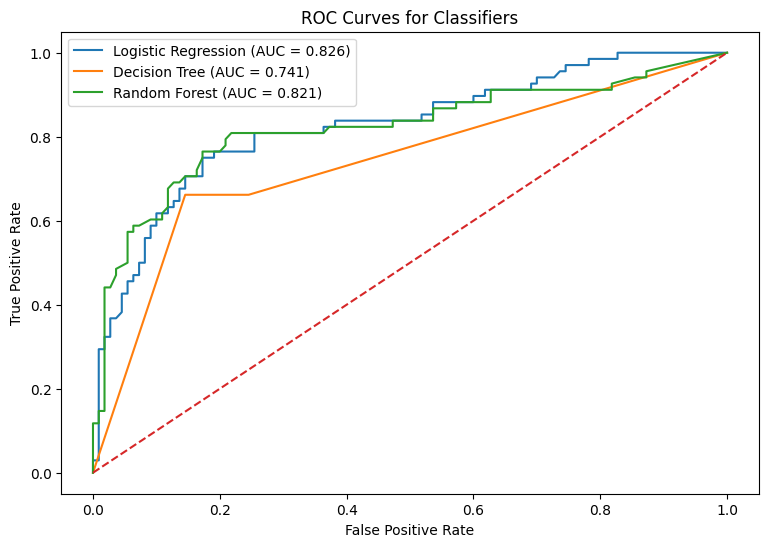

=== AUC SCORES ===
Logistic Regression: 0.8265
Decision Tree: 0.7412
Random Forest: 0.8211


In [26]:
# ROC Curves and AUC

from sklearn.metrics import roc_curve, roc_auc_score

logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]
decision_tree_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]
random_forest_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probabilities)
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_probabilities)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_probabilities)

logistic_auc = roc_auc_score(y_test, logistic_probabilities)
decision_tree_auc = roc_auc_score(y_test, decision_tree_probabilities)
random_forest_auc = roc_auc_score(y_test, random_forest_probabilities)

plt.figure(figsize=(9, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    decision_tree_fpr,
    decision_tree_tpr,
    label=f"Decision Tree (AUC = {decision_tree_auc:.3f})"
)

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label=f"Random Forest (AUC = {random_forest_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curves for Classifiers")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("=== AUC SCORES ===")
print(f"Logistic Regression: {logistic_auc:.4f}")
print(f"Decision Tree: {decision_tree_auc:.4f}")
print(f"Random Forest: {random_forest_auc:.4f}")

In [27]:
# Final classifier comparison table

comparison_table = metrics_table.copy()

comparison_table["AUC"] = [
    logistic_auc,
    decision_tree_auc,
    random_forest_auc
]

display(comparison_table.round(4))

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.7809,0.7544,0.6324,0.6880,0.8265
Decision Tree,0.7697,0.7143,0.6618,0.6870,0.7412
Random Forest,0.7978,0.7759,0.6618,0.7143,0.8211


In [28]:
!pip install -q imbalanced-learn

In [29]:
import imblearn

print("imbalanced-learn version:", imblearn.__version__)
print("SMOTE package is ready.")

imbalanced-learn version: 0.14.2
SMOTE package is ready.


In [30]:
# Baseline Logistic Regression

baseline_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_logistic.fit(X_train, y_train)

baseline_predictions = baseline_logistic.predict(X_test)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [31]:
class_weight="balanced"

In [32]:
# Class-weight balanced Logistic Regression

balanced_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_logistic.fit(X_train, y_train)

balanced_predictions = balanced_logistic.predict(X_test)

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


In [33]:
# SMOTE Logistic Regression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_logistic = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

smote_logistic.fit(X_train, y_train)

smote_predictions = smote_logistic.predict(X_test)

print("SMOTE Logistic Regression trained successfully.")

SMOTE Logistic Regression trained successfully.


In [34]:
# Compare imbalance strategies

from sklearn.metrics import precision_score, recall_score, f1_score

imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_predictions),
        precision_score(y_test, balanced_predictions),
        precision_score(y_test, smote_predictions)
    ],
    "Recall": [
        recall_score(y_test, baseline_predictions),
        recall_score(y_test, balanced_predictions),
        recall_score(y_test, smote_predictions)
    ],
    "F1": [
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, balanced_predictions),
        f1_score(y_test, smote_predictions)
    ]
})

display(imbalance_results.round(4))

,Strategy,Precision,Recall,F1
0,Baseline,0.7544,0.6324,0.6880
1,Class Weight Balanced,0.7500,0.7059,0.7273
2,SMOTE,0.7460,0.6912,0.7176


Conclusion

The class-weight balanced strategy produced the highest recall (0.7059) and highest F1 score (0.7273) among the three imbalance-handling approaches. Compared with the baseline, it increased recall from 0.6324 to 0.7059 while keeping precision close at 0.7500. SMOTE also improved recall and F1 compared with the baseline, but its F1 score (0.7176) was lower than the class-weight balanced approach. Therefore, class weighting provided the strongest balance between precision and recall for this test split.

In [35]:
# Random Forest GridSearchCV setup

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_for_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Random Forest GridSearchCV is ready.")
print("Total parameter combinations:", 12)

Random Forest GridSearchCV is ready.
Total parameter combinations: 12


In [36]:
# Run Random Forest GridSearchCV

print("Starting GridSearchCV...")

rf_grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully.")
print("\nBest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(round(rf_grid_search.best_score_, 4))

Starting GridSearchCV...
GridSearchCV completed successfully.

Best parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best cross-validation F1 score:
0.7436


In [37]:
# Best Random Forest OOB score

best_rf_pipeline = rf_grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["classifier"]

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(round(rf_grid_search.best_score_, 4))

print("\nOOB score:")
print(round(best_rf_model.oob_score_, 4))

Best Random Forest parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best cross-validation F1 score:
0.7436

OOB score:
0.8073


In [38]:
# Prepare regression dataset

regression_df = model_df.drop(columns=["fare"]).copy()

X_reg = regression_df.drop(columns=["survived"])
y_reg = model_df["fare"]

print("Regression features:")
print(X_reg.columns.tolist())

print("\nFeatures shape:", X_reg.shape)
print("Target shape:", y_reg.shape)
print("Target: fare")

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Features shape: (889, 12)
Target shape: (889,)
Target: fare


In [39]:
# Regression train/test split

from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression split completed.")
print("X_reg_train:", X_reg_train.shape)
print("X_reg_test:", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test:", y_reg_test.shape)

Regression split completed.
X_reg_train: (711, 12)
X_reg_test: (178, 12)
y_reg_train: (711,)
y_reg_test: (178,)


In [40]:
# Regression preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

reg_numeric_features = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

reg_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

print("Numeric features:", reg_numeric_features)
print("Categorical features:", reg_categorical_features)
print("Regression preprocessing is ready.")

Numeric features: ['pclass', 'age', 'sibsp', 'parch']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
Regression preprocessing is ready.


In [41]:
# Multivariate Linear Regression

from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

regression_predictions = regression_pipeline.predict(X_reg_test)

print("Multivariate Linear Regression trained successfully.")
print("Predictions generated:", len(regression_predictions))

Multivariate Linear Regression trained successfully.
Predictions generated: 178


In [42]:
# Regression evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, regression_predictions)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, regression_predictions)
)

r2 = r2_score(y_reg_test, regression_predictions)

n = len(y_reg_test)
p = regression_pipeline.named_steps["preprocessor"].transform(
    X_reg_test
).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("=== REGRESSION METRICS ===")
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"\nObservations (n): {n}")
print(f"Predictors (p):   {p}")

=== REGRESSION METRICS ===
MAE:         18.3735
RMSE:        41.2921
R²:          0.3609
Adjusted R²: 0.2607

Observations (n): 178
Predictors (p):   24


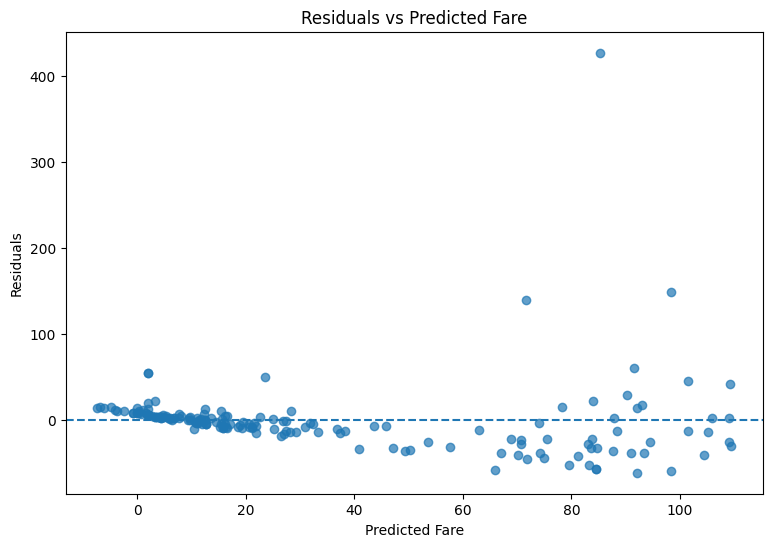

In [43]:
# Residual plot

residuals = y_reg_test - regression_predictions

plt.figure(figsize=(9, 6))

plt.scatter(
    regression_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Fare")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

Heteroscedasticity Conclusion

The residual plot shows that the spread of residuals is not completely constant across the range of predicted fare values. The residuals become more dispersed at higher predicted values, indicating evidence of heteroscedasticity. This suggests that the variance of the regression errors changes with the predicted fare, so the constant-variance assumption is not fully satisfied.

In [44]:
# Final classifier comparison

final_classifier_table = comparison_table[
    ["Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

display(final_classifier_table.round(4))

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.7809,0.7544,0.6324,0.6880,0.8265
Decision Tree,0.7697,0.7143,0.6618,0.6870,0.7412
Random Forest,0.7978,0.7759,0.6618,0.7143,0.8211


In [45]:
# Regression metrics

regression_metrics = pd.DataFrame({
    "MAE": [18.3735],
    "RMSE": [41.2921],
    "R2": [0.3609],
    "Adjusted R2": [0.2607]
}, index=["Linear Regression"])

display(regression_metrics)

,MAE,RMSE,R2,Adjusted R2
Linear Regression,18.3735,41.2921,0.3609,0.2607


Final Recommendation

Among the three classifiers, Random Forest achieved the highest test accuracy (0.7978) and the highest F1 score (0.7143), while also achieving the highest precision (0.7759). Logistic Regression achieved a slightly higher ROC AUC (0.8265) than Random Forest (0.8211), indicating strong overall ranking performance. Decision Tree achieved the same recall as Random Forest (0.6618) but had lower accuracy, precision, F1 and AUC. Based on the overall test-set metrics, the Random Forest classifier is selected as the deployment candidate because it provides the strongest combination of accuracy, precision and F1 score on this test split.

In [46]:
# Save the complete model pipeline

import joblib

full_pipeline = random_forest_pipeline

joblib.dump(full_pipeline, "model_pipeline.joblib")

print("Complete model pipeline saved successfully.")

Complete model pipeline saved successfully.


In [47]:
# Reload the saved pipeline

loaded_pipeline = joblib.load("model_pipeline.joblib")

print("Pipeline reloaded successfully.")
print("Pipeline steps:", loaded_pipeline.named_steps.keys())

Pipeline reloaded successfully.
Pipeline steps: dict_keys(['preprocessor', 'classifier'])


In [48]:
# Test the reloaded pipeline on raw input

raw_test_input = X_test.head(1)

prediction = loaded_pipeline.predict(raw_test_input)

print("Raw input shape:", raw_test_input.shape)
print("Prediction:", prediction)
print("Predicted survival status:",
      "Survived" if prediction[0] == 1 else "Did Not Survive")

Raw input shape: (1, 13)
Prediction: [0]
Predicted survival status: Did Not Survive
